### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




#### Reading in the datafile

In [2]:
filepath = r"C:\Users\MKAWIMB\OneDrive - Daimler Truck\Projects\Python\5_Practical Application 1\Data\coupons.csv"
data = pd.read_csv(filepath)
data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


2. Investigate the dataset for missing or problematic data.

#### Exploratory Data Analysis

In [3]:
# Using the pandas method 'info()' to get field data types and a sense of NaN/null value count
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [4]:
 # Calculating the % of NaN values in each column leveraging the 'isnull()' and 'sum()' pandas methods
data.isnull().sum()
(data.isnull().sum() / len(data)) * 100

destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

In [5]:
# Using the 'describe()' method to get a statistical summary of the numerical columns
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


3. Decide what to do about your missing data -- drop, replace, other...

In [6]:
# Based on the %'s of nulls, we drop the 'car' column and the raws containing NaN.
data = data.drop("car", axis=1)
data = data.dropna()

In [7]:
#Checking if the null values have been addressed
data.isnull().sum()
(data.isnull().sum() / len(data)) * 100

destination             0.0
passanger               0.0
weather                 0.0
temperature             0.0
time                    0.0
coupon                  0.0
expiration              0.0
gender                  0.0
age                     0.0
maritalStatus           0.0
has_children            0.0
education               0.0
occupation              0.0
income                  0.0
Bar                     0.0
CoffeeHouse             0.0
CarryAway               0.0
RestaurantLessThan20    0.0
Restaurant20To50        0.0
toCoupon_GEQ5min        0.0
toCoupon_GEQ15min       0.0
toCoupon_GEQ25min       0.0
direction_same          0.0
direction_opp           0.0
Y                       0.0
dtype: float64

4. What proportion of the total observations chose to accept the coupon?



In [8]:
# To get the proportion, divide the number of records with Y = 1 by the total number of records.
((data['Y'] == 1).sum() / len(data))*100

np.float64(56.93352098683666)

5. Use a bar plot to visualize the `coupon` column.

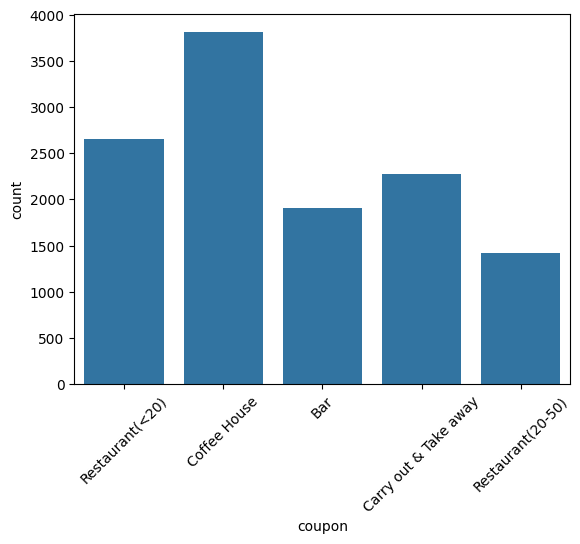

In [9]:
# Seaborn's countplot() will count the number of instances of each coupon type and create a bar chart
sns.countplot(data=data, x='coupon')
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

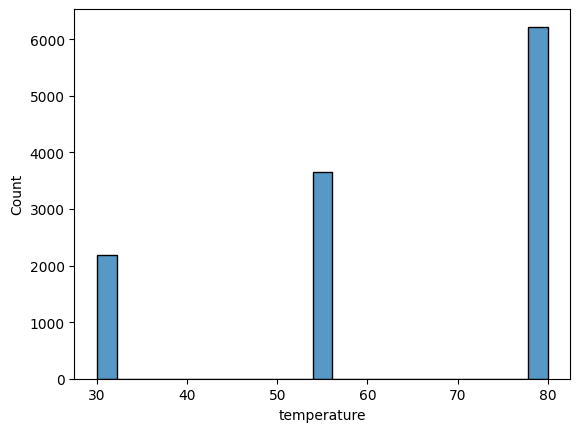

In [10]:
# Using seaborn's 'histplot()' function plot a histogram
sns.histplot(data=data, x="temperature")
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [11]:
bar_data = data[data["coupon"]=="Bar"]
bar_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [12]:
# Total number who received bar coupons
tot_bar_goers = len(bar_data)

# Number who accepted bar coupons
accepted_bar_coupons = len(bar_data.query('Y==1'))

print("% of bar coupons accepted: ", (accepted_bar_coupons / tot_bar_goers) * 100)

% of bar coupons accepted:  41.19184526921067


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [13]:
# Get the size of each group
fewer_group_size = len(bar_data.query('Bar==["never", "less1", "1~3"]'))
more_group_size = len(bar_data.query('Bar==["4~8", "gt8"]'))

# Get number who accepted in each group
less_than_3_accepted = len(bar_data.query('Bar==["never", "less1", "1~3"] and Y==1'))
more_than_3_accepted = len(bar_data.query('Bar==["4~8", "gt8"] and Y==1'))

print("3 visits or less:", (less_than_3_accepted / fewer_group_size) * 100)
print("More than 3 visits:", (more_than_3_accepted / more_group_size) * 100)

3 visits or less: 37.26744186046512
More than 3 visits: 76.16580310880829


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [14]:
# Let's get visibility to all the values in the age column
sorted(bar_data['age'].unique())

['21', '26', '31', '36', '41', '46', '50plus', 'below21']

In [15]:
# We need to clean the data so that "grouped ages" fall on the right side of 25
bar_data["age"] = bar_data["age"].str.replace("50plus", "50")
bar_data["age"] = bar_data["age"].str.replace("below21", "21")

In [16]:
# Let's check if letters have been removed
sorted(bar_data['age'].unique())

['21', '26', '31', '36', '41', '46', '50']

In [17]:
# Note that age is actually data type str. So convert to numeric
bar_data["age"] = pd.to_numeric(bar_data["age"])

In [18]:
# Confirming the age data type is now numeric
bar_data["age"].dtypes

dtype('int64')

In [19]:
# Number in each group
grp_in_question = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and age>25'))
all_others = len(bar_data.query('Bar not in ["1~3", "4~8", "gt8"] and age<=25'))

# Number who accepted bar coupons in each group
grp_in_question_accepted = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and age>25 and Y==1'))
all_others_accepted = len(bar_data.query('Bar not in ["1~3", "4~8", "gt8"] and age<=25 and Y==1'))

print("Acceptance rate of group in question: ", (grp_in_question_accepted / grp_in_question) * 100)
print("Acceptance rate of all others: ", (all_others_accepted / all_others) * 100)
print("Conclusion: There is a difference.")

Acceptance rate of group in question:  68.98263027295285
Acceptance rate of all others:  38.83495145631068
Conclusion: There is a difference.


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [20]:
# Firstly, the column passenger seems to be misspelt. Let's address that.
bar_data = bar_data.rename(columns={"passanger": "passenger"})
bar_data.sample(3)

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9334,Work,Alone,Rainy,55,7AM,Bar,1d,Female,46,Divorced,...,1~3,1~3,1~3,1~3,1,1,1,0,1,0
12421,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,31,Married partner,...,less1,4~8,1~3,4~8,1,1,0,0,1,0
7159,No Urgent Place,Friend(s),Rainy,55,10PM,Bar,2h,Male,31,Married partner,...,never,4~8,4~8,1~3,1,1,0,0,1,1


In [21]:
# Let's get visibility to all the values in the 'passenger' column
sorted(bar_data["passenger"].unique())

['Alone', 'Friend(s)', 'Kid(s)', 'Partner']

In [22]:
# Let's get visibility to all the values in the 'occupation' column
sorted(bar_data["occupation"].unique())

['Architecture & Engineering',
 'Arts Design Entertainment Sports & Media',
 'Building & Grounds Cleaning & Maintenance',
 'Business & Financial',
 'Community & Social Services',
 'Computer & Mathematical',
 'Construction & Extraction',
 'Education&Training&Library',
 'Farming Fishing & Forestry',
 'Food Preparation & Serving Related',
 'Healthcare Practitioners & Technical',
 'Healthcare Support',
 'Installation Maintenance & Repair',
 'Legal',
 'Life Physical Social Science',
 'Management',
 'Office & Administrative Support',
 'Personal Care & Service',
 'Production Occupations',
 'Protective Service',
 'Retired',
 'Sales & Related',
 'Student',
 'Transportation & Material Moving',
 'Unemployed']

In [23]:
# Let's get the acceptance rate of the group
# Note: It is assumed that the driver must a passenger, so if they are alone, they are excluded from the group.
grp_in_ques = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and passenger not in ["Alone", "Kid(s)"] and occupation != "Farming Fishing & Forestry"'))
grp_in_ques_accpt = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and passenger not in ["Alone", "Kid(s)"] and occupation != "Farming Fishing & Forestry" and Y==1'))
print("The acceptance rate for the group is: ", (grp_in_ques_accpt / grp_in_ques) * 100)

The acceptance rate for the group is:  71.42857142857143


In [24]:
# Let's get the acceptance rate of others
others = len(bar_data.query('Bar not in ["1~3", "4~8", "gt8"] and passenger in ["Alone", "Kid(s)"] and occupation == "Farming Fishing & Forestry"'))
others_accpt = len(bar_data.query('Bar not in ["1~3", "4~8", "gt8"] and passenger in ["Alone", "Kid(s)"] and occupation == "Farming Fishing & Forestry" and Y==1'))
print("The acceptance rate for others is: ", (others_accpt / others) * 100)

The acceptance rate for others is:  50.0


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [25]:
# Acceptance rate of 'not widowed' group
sorted(bar_data["maritalStatus"].unique())

['Divorced', 'Married partner', 'Single', 'Unmarried partner', 'Widowed']

In [26]:
not_widowed = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and passenger not in ["Alone", "Kid(s)"] and maritalStatus != "Widowed"'))
not_widowed_accpt = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and passenger not in ["Alone", "Kid(s)"] and maritalStatus != "Widowed" and Y==1'))
print("The acceptance rate for not widowed is: ", (not_widowed_accpt / not_widowed) * 100)

The acceptance rate for not widowed is:  71.42857142857143


In [27]:
# Acceptance rate of 'under 30' group
under_30 = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and age<30'))
under_30_accpt = len(bar_data.query('Bar in ["1~3", "4~8", "gt8"] and age<30 and Y==1'))
print("The acceptance rate for under 30 is: ", (not_widowed_accpt / not_widowed) * 100)

The acceptance rate for under 30 is:  71.42857142857143


In [28]:
# Acceptance rate of 'make less than 50k' group
sorted(bar_data["RestaurantLessThan20"].unique())

['1~3', '4~8', 'gt8', 'less1', 'never']

In [29]:
sorted(bar_data["income"].unique())

['$100000 or More',
 '$12500 - $24999',
 '$25000 - $37499',
 '$37500 - $49999',
 '$50000 - $62499',
 '$62500 - $74999',
 '$75000 - $87499',
 '$87500 - $99999',
 'Less than $12500']

In [30]:
less_than_50 = len(bar_data.query('RestaurantLessThan20 in ["4~8", "gt8"] and income in ["Less than $12500", "$12500 - $24999","$25000 - $37499","$37500 - $49999"]'))
less_than_50_accpt = len(bar_data.query('RestaurantLessThan20 in ["4~8", "gt8"] and income in ["Less than $12500", "$12500 - $24999","$25000 - $37499","$37500 - $49999"] and Y==1'))
print("The acceptance rate for less than 50k is: ", (less_than_50_accpt / less_than_50) * 100)

The acceptance rate for less than 50k is:  45.645645645645644


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [31]:
# Drivers not traveling with kids are more likely to accept the bar coupons. They are probably not weighed down by family commitments.
# Bars tend not to be kid friendly so those without kids do not experience this inconvenience.

# Being younger (under the age of 30) and past behavior of going to bars seem to be significant factors in the acceptance of the coupons.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

##### Analyze the influence of temperature on coffee house coupon acceptance rate of drivers while holding the frequency of past visits and weather constant.

In [32]:
# Importing Plotly package for Exploratory Data Analysis
import plotly.express as px

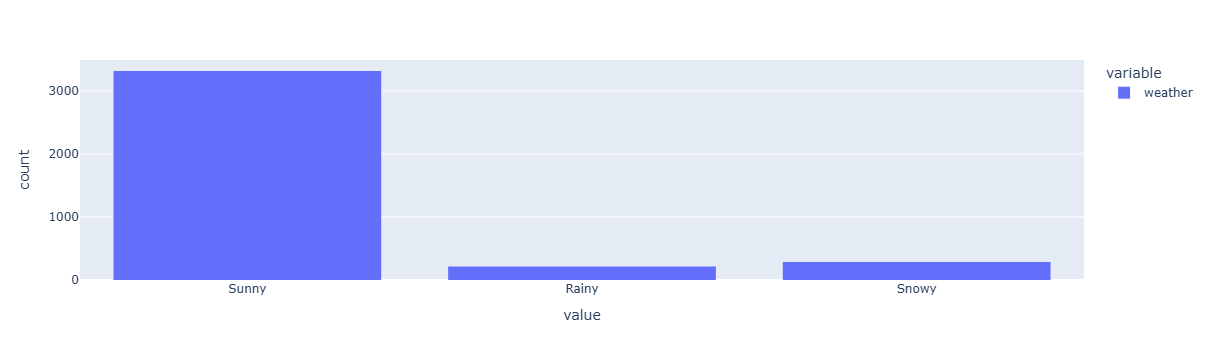

In [33]:
# Get an idea of the weather data distribution
px.histogram(data.query('coupon=="Coffee House"')["weather"])

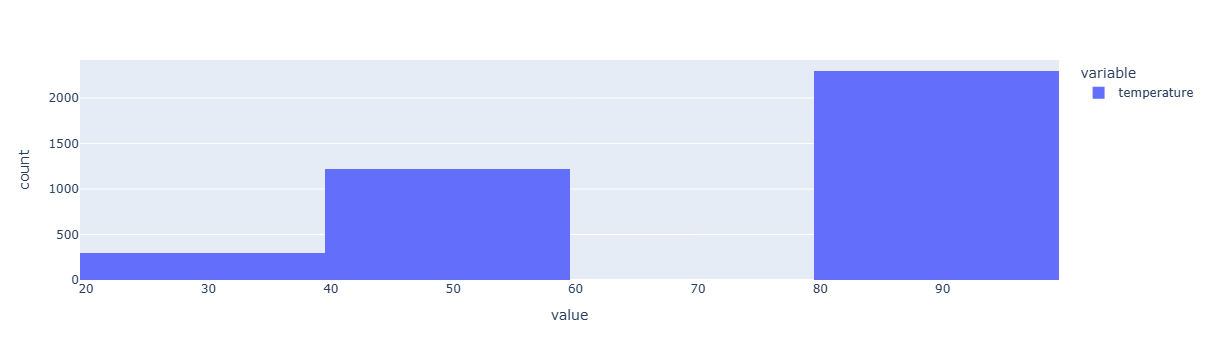

In [34]:
# Get an idea of the temperature data distribution
px.histogram(data.query('coupon=="Coffee House"')["temperature"])

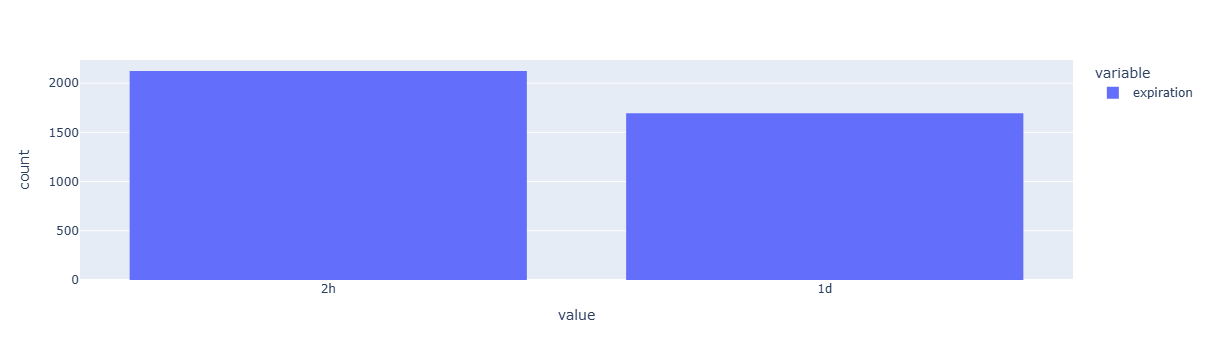

In [35]:
# Get an idea of the expiration data distribution
px.histogram(data.query('coupon=="Coffee House"')["expiration"])

In [36]:
ch_data = data[data["coupon"]=="Coffee House"]
ch_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
27,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
28,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
30,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


In [37]:
# Acceptance rate of 'hot-sunny' group
hot_sunny = len(ch_data.query('CoffeeHouse in ["4~8", "gt8"] and weather=="Sunny" and temperature>60'))
hot_sunny_accpt = len(ch_data.query('CoffeeHouse in ["4~8", "gt8"] and weather=="Sunny" and temperature>60 and Y==1'))
print("The acceptance rate for hot sunny weather is: ", (hot_sunny_accpt / hot_sunny) * 100)

The acceptance rate for hot sunny weather is:  73.22515212981745


In [38]:
# Acceptance rate of 'mid-sunny' group
mid_sunny = len(ch_data.query('CoffeeHouse in ["4~8", "gt8"] and weather=="Sunny" and (temperature>=40 and temperature<=60)'))
mid_sunny_accpt = len(ch_data.query('CoffeeHouse in ["4~8", "gt8"] and weather=="Sunny" and (temperature>=40 and temperature<=60) and Y==1'))
print("The acceptance rate for mild sunny weather is: ", (mid_sunny_accpt / mid_sunny) * 100)

The acceptance rate for mild sunny weather is:  60.88888888888889


In [39]:
# Acceptance rate of 'cold-sunny' group
cold_sunny = len(ch_data.query('CoffeeHouse in ["4~8", "gt8"] and weather=="Sunny" and temperature<40'))
cold_sunny_accpt = len(ch_data.query('CoffeeHouse in ["4~8", "gt8"] and weather=="Sunny" and temperature<40 and Y==1'))
print("The acceptance rate for cold sunny weather is: ", (cold_sunny_accpt / cold_sunny) * 100)

The acceptance rate for cold sunny weather is:  80.0


##### Deduction

In [40]:
#It would appear that holding visits and weather constant, relatively high and low temperatures make it more likely for drivers to accept coupons.
#Higher temperatures tend to encourage driver to pursue cold beverages and lower temperatures hot beverages.